# Atomic Force Microscopy Contact Model Tutorial 

# Overview of AFM and Contact Mechanics Models

This notebook provides an interactive introduction to Atomic Force Microscopy (AFM) and the fundamental contact mechanics models used to describe tip-sample interactions, including Hertz contact, Johnson–Kendall–Roberts (JKR) contact, and Ting's model.

---

1. [Introduction to AFM](#1-introduction-to-afm)  
2. [Hertz Contact Model](#2-hertz-contact-model)  
   - [2.1 Introduction to Hertz Contact](#21-introduction-to-hertz-contact)  
   - [2.2 Force vs Displacement Plots for Hertz Contact](#22-force-vs-displacement-plots-for-hertz-contact)  
3. [JKR Contact Model](#3-jkr-contact-model)  
   - [3.1 Introduction to JKR Contact](#31-introduction-to-jkr-contact)  
   - [3.2 Force vs Displacement Plots for JKR Contact](#32-force-vs-displacement-plots-for-jkr-contact)  

## 1. Introduction to AFM

Atomic Force Microscopy (AFM) is a high-resolution imaging technique that can map surface topography at the nanoscale, and measure forces between a probe and sample, among other uses. AFM works by scanning a sharp tip over a sample's surface, measuring the forces between the tip and the sample. These forces can be used to extract material properties such as those pertaining to surface roughness, adhesion, stiffness, and viscoelasticity.

AFM can operate in various modes, including contact mode, tapping mode, and non-contact mode, depending on the application. Understanding the interaction forces between the AFM tip and the sample is crucial for accurate material characterization, and this is where contact mechanics models come into play.


## 2. Hertz Contact Model

### 2.1 Introduction to Hertz Contact

The Hertz contact theory was developed by **Heinrich Hertz** in 1881. Hertz formulated the theory for how two elastic half-spaces (elastic materials that extend infinitely in all directions including depth with the surface at the top considered as the boundary) deform under compressive forces. The model laid the groundwork for many applications in engineering and physics, including AFM. 

The Hertz contact theory describes the interaction between two elastic bodies in contact, providing a model for the deformation and force response. It is commonly applied to describe the behavior of AFM tips in contact with the sample surface in the contact mode of AFM.

**Assumptions in Hertzian theory:**

- The strains are small and within the elastic limit.

- The surfaces are continuous and non-conforming (the area of contact is much smaller than the characteristic dimensions of the contacting bodies).

- Each body can be considered an elastic half-space.

- The surfaces are frictionless.

- The model calculates the force required to deform the sample as a function of the indentation depth and the material properties of both the tip and the sample.

The contact theory between elastic bodies can be ued to find contact areas and indentation dpeths for simple geomtries. A commonly used solution is for contact between two spheres.

For this solution, force is solved for given indentation where $F$ is force, $E^{\text{*}}$ is effective modulus, $R^{\text{*}}$ is effective radius, and $\delta$ is indentation.

*Note that equations below are from a standard textbook for Hertz theory: Johnson, K.L.. (1985). <i>Contact Mechanics - 4.1 Geometry of Smooth, Non-Conforming Surfaces in Contact.</i> (pp. 84). Cambridge University Press. Retrieved from <br>https://app.knovel.com/hotlink/pdf/id:kt006OUR11/contact-mechanics/geometry-smooth-non-conforming

Equations in this book are derivatves of Hertz's original paper: H. Hertz, "Über die Berührung fester elastischer Körper," Journal für die reine und angewandte Mathematik, vol. 92, pp. 156–171, 1882.


Below, see how this sphere-to-sphere contact model can be implemented in Python:

First, import some useful libaries.

In [464]:
# Import useful libraries
import numpy as np
import matplotlib.pyplot as plt

Next, define how the effective modulus, effective radius, and force are calculated.

$$
E^* = \frac{1}{\frac{1}{1-v_1^2}+\frac{1}{1-v_2^2}}
$$

$$
R^* = \frac{1}{\frac{1}{r_1} + \frac{1}{r_2}}
$$

$$
F = \frac{4}{3} E^{\text{*}} {R^{\text{*1/2}}} \delta^{3/2}
$$


In [466]:
# Define how effective modulus, effective radius, and force are calculated
def calc_e_eff(e1, e2, v1, v2):
    return 1 / ((1 - v1**2) / e1 + (1 - v2**2) / e2)

def calc_r_eff(r1, r2):
    return 1 / (1 / r1 + 1 / r2)

def calc_force(deformation, e_eff, r_eff):
    return (4.0 / 3) * e_eff * np.sqrt(r_eff) * deformation**1.5

In the code below, material properties and a deformation vector are defined. Feel free to change material properties to see the effect on force required to indent. Note that deformation should be capped at 1nm. This is due to the assumtion that the area of contact is much less than the radius of the sphere.


In [468]:
# Material properties
e_values = [1.3e9, 2.5e9, 18e9]  # Sample modulus (Pa), different values (polypropelynene, pmma, bone)  
tip_modulus_values = [300e9]  # Tip modulus (Pa),
v1, v2 = 0.3, 0.3  # Poisson's ratio
r1, r2 = 10e-9, 5e-3  # Radii (m); r1 is tip radius, sample radius is negligible when r* is calculated

In [469]:
deformation = np.linspace(1e-11, 1e-9, num=10)  # Deformation in meters (.01 nm to 1 nm)


Next, plot the results.

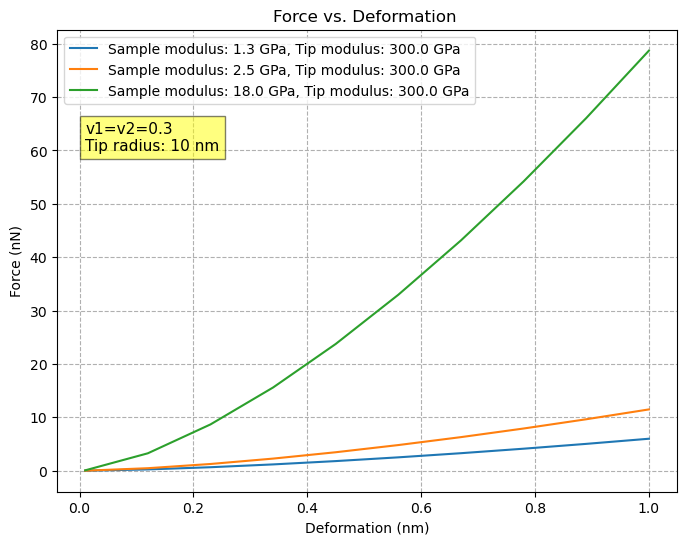

In [471]:
# Plot results
plt.figure(figsize=(8, 6))

# Loop through different modulus values
for e1 in e_values:
    for e2 in tip_modulus_values:
        e_eff = calc_e_eff(e1, e2, v1, v2)
        r_eff = calc_r_eff(r1, r2)
        f = calc_force(deformation, e_eff, r_eff)  # Force in N
        
        # Plot Force vs Deformation
        label = f'Sample modulus: {e1/1e9} GPa, Tip modulus: {e2/1e9} GPa'
        plt.plot(deformation * 1e9, f * 1e9, label=label)  # Convert force to nN and deformation to nm

plt.xlabel('Deformation (nm)')
plt.ylabel('Force (nN)')
plt.title('Force vs. Deformation ')
plt.legend()
plt.grid(True, which="both", linestyle="--")
info_text2 = 'v1=v2=0.3\nTip radius: 10 nm' #FIXME make sure to change so it updates if v1 or v2 changes
plt.text(0.01, 60, info_text2, fontsize=11, bbox=dict(facecolor='yellow', alpha=0.5))
plt.show()

Other information that may be of use is the pressure distribution for a given force. For sphere-sphere contact, the contact radius is given by:

$$
a = ({\frac{3FR^{\text{*}}}{4E^{\text{*}}}})^{\text{1/3}}
$$

From this, maximum pressure at the center of the circular contact is given by:

$$
P_{max} = \frac{3F}{2\pi a^2}
$$

For spheres, the pressure distribution is given by the equation below where r is some tip radius r.

$$
P(r) = P_{max}(1 - (r/a)^2))^{1/2}
$$

Try changing the material properties above to see the effect.

Since contact radius is defined for a given force, define some force values from the force vector calculated earlier. Feel free to define a different force value from the force vector calculated earlier by uncommenting 'f_choice'.

In [474]:
# Force Values
f_start = f[0] #force for minimum defined deformation
f_end = f[-1] #force for maximum defined deformation 
def_start = deformation[0]
def_end = deformation[-1]
# f_choice = f[] # uncomment to define a force value using a different index in the force vector
# def_choice = deformation[] # choose the same array value to choose the deformation corresponding to the chosen force

Next, choose a force to calculate the pressure distribution with. 

*Note that the pressure distribution with default values and the force for maximum defined deformation should yield a max pressure of one order of magnitude higher than with the force for minimum defined deformation.

In [476]:
option = 2 # choose an option for which force to calculate the pressure distribution
if(option == 1):
    f_pressure_dist = f_start
    def_pressure_dist = def_start
if(option == 2):
    f_pressure_dist = f_end
    def_pressure_dist = def_end
if(option == 3):
    f_pressure_dist = f_choice
    def_pressure_dist = def_choice

Now, contact radius, $a$ can be calculated. 

In [478]:
# Contact radius calculation for a given force 
a = (3 * f_pressure_dist * r_eff / (4 * e_eff)) ** (1/3) # final contact area radius

Next, make a vector of radii between $-a$  and  $a$.

In [480]:
r_vect = np.linspace(-a, a, 50) # contact points from -a to a (various radii)

Calculate maximum pressure.

In [482]:
# Maximum pressure calculation
p0 = 3 * f_pressure_dist / (2*np.pi * a ** 2) # maximum pressure for a given force

Finally, a pressure distribution can be calculated. 

In [484]:
# Pressure Distribution
p_vect = p0 * (1 - (r_vect/a)**2)**(1/2) # pressure distribution

Plot results for force vs deflection and plot pressure distribution against radius.

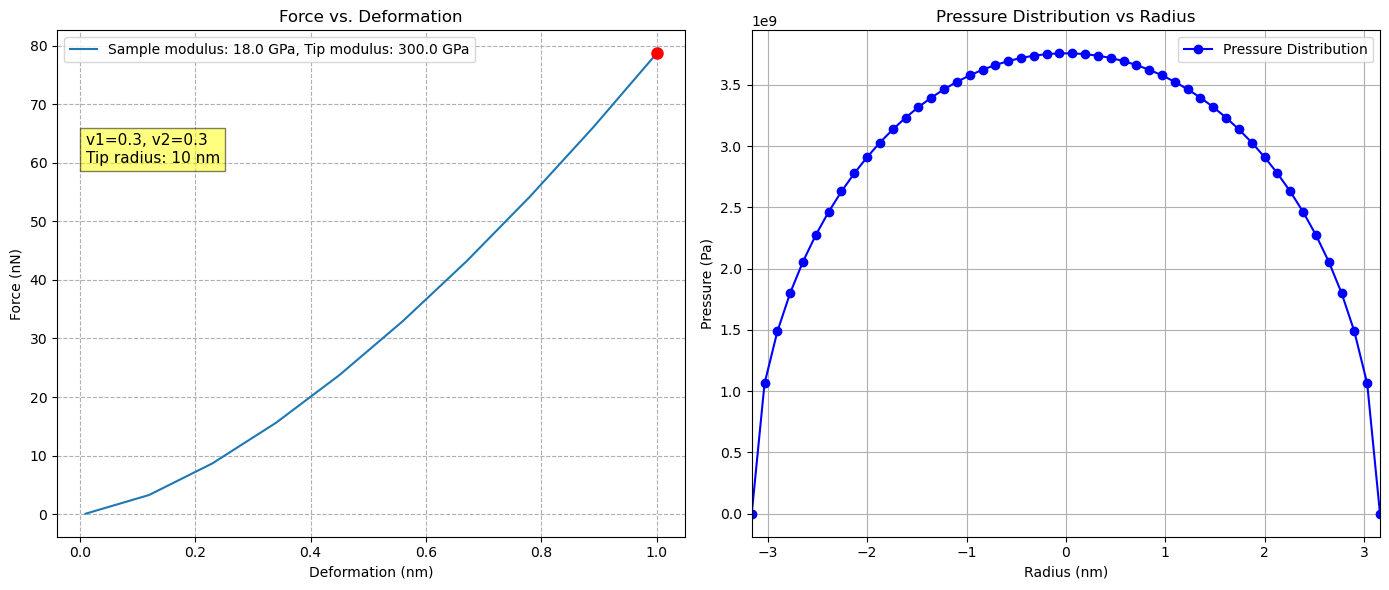

In [486]:
# Create side-by-side subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Plot Force vs Deformation
f = calc_force(deformation, e_eff, r_eff)  # Force in N
        
label = f'Sample modulus: {e1/1e9:.1f} GPa, Tip modulus: {e2/1e9:.1f} GPa'
axs[0].plot(deformation * 1e9, f * 1e9, label=label)  # nm vs nN

axs[0].set_xlabel('Deformation (nm)')
axs[0].set_ylabel('Force (nN)')
axs[0].set_title('Force vs. Deformation')
axs[0].legend()
axs[0].grid(True, which="both", linestyle="--")
info_text2 = f'v1={v1}, v2={v2}\nTip radius: {r1*1e9:.0f} nm'
axs[0].text(0.01, 60, info_text2, fontsize=11, bbox=dict(facecolor='yellow', alpha=0.5))

# Plot chosen force for pressure distribution
axs[0].plot(def_pressure_dist*1e9, f_pressure_dist*1e9, 'ro', markersize=8)  # Plot on the first subplot

# Plot pressure distribution
axs[1].plot(r_vect * 1e9, p_vect, marker='o', linestyle='-', color='b', label='Pressure Distribution')
axs[1].set_xlabel("Radius (nm)")
axs[1].set_ylabel("Pressure (Pa)")
axs[1].set_title("Pressure Distribution vs Radius")
axs[1].legend()
axs[1].grid(True)
axs[1].set_xlim(min(r_vect * 1e9), max(r_vect * 1e9))

plt.tight_layout()
plt.show()


In the plot of results, the **red marker** indicates the force at which the pressure distribution has been found.

## 3. JKR Contact Model

### 3.1 Introduction to JKR Contact
The **Johnson-Kendall-Roberts (JKR)** theory builds upon the Hertz model but incorporates adhesion between the surfaces due to Van der Waals forces within the contact zone. While the model accounts for adhesion, it still assumes elasticity and is limited to strongly adhesive systems (usually materials with low elastic moduls)
While not shown due to the complexity of the derivation, this model is derived by considering the total energy of the system including the energy due to elastic deformation, the mechanical energy required to deform the bodies, and the surface energy due to adhesion.

Johnson, K. L. , K. Kendall, and A. D. Roberts, "Surface energy and the contact of elastic solids," Proc. R.
Soc. Lond. A, vol. 324, no. 1558, pp. 301–313, Sep. 1971, doi: 10.1098/rspa.1971.0141.


In [489]:
# Material properties & parameters for JKR
gamma = 80.2e-3  # J/m^2 (Surface energy) 
# Although material properties are already defined above, they are redefined here to allow for calculation and visualization of PMMA JKR model
e1 = 2.5e9       # Pa (PMMA modulus)
e2 = 300e9       # Pa (tip modulus)
v1 = 0.3         # (sample Poison's ratio)  
v2 = 0.3         # (tip Poison's ratio) 
r1 = 10e-9       # m (tip radius)
r2 = 5e-3        # m (sample radius)
# Recalculate e-eff for visualization of PMMA JKR model
e_eff = calc_e_eff(e1, e2, v1, v2)

JKR force is the total force between the two spherical bodies and includes the applied load as well as the load due to adhesion. Here, $F_{JKR}$ is given in terms of the contact radius $a$.
  $$
  F^{JKR} = \frac{4 E^* a^3}{3 R^*} + \sqrt{16 \pi \gamma E^* a^3}
  $$

If one solves for contact radius in terms of $F_{JKR}$, one finds:
  $$
  a = \frac{-4\sqrt{\pi\gamma E^*}\pm \sqrt{16\pi \gamma E^*+16E^*F^{JKR}/3R}}{8E^*/3R}
  $$

*This is a modified equation 5.49 from "Contact Mechanics".

Indentation depth, $\delta$ is also given in terms of the contact radius $a$. Since the contact radius $a$ has been solved for, one can also solve for indentation depth.

$$
\delta = \frac{\pi * a}{2* E^*} \times (p_0 +2p^{\prime}_0)
$$

Where pressure adhesive and non-adhesive pressure distributions are $p_0$ = $\frac{2aE^*}{\pi R}$ and $p^{\prime}_0 = -\sqrt(4\gamma*E^*/\pi a)$. *This is equation 5.46, 5.44.1 and 5.48 from "Contact Mechanics".

Once one plugs in values of $p_0$ and $p^{\prime}_0$, one finds:

$$
\delta = \frac{\pi * a}{2* E^*} \times (\frac{2aE^*}{\pi R} -2\sqrt(4\gamma*E^*/\pi a)
$$

Source: Johnson, K.L.. (1985). <i>Contact Mechanics - 5.5 Adhesion between Elastic Bodies.</i> (pp. 125). Cambridge University Press. Retrieved from <br>https://app.knovel.com/hotlink/pdf/id:kt006OUR94/contact-mechanics/adhesion-between-elastic

First, define functions for the contact radius, $a$. The equations above have been used, and the discriminant is filtered to remove non-real numbers from outputs.

In [492]:
def contact_radius_calc_pos(f_vals, r_eff, e_eff, gamma):
    discriminant = 16*np.pi*gamma*e_eff + (16/(3*r_eff))*e_eff*f_vals
    discriminant = np.where(discriminant >= 0, discriminant, np.nan)
    return (((-4*np.sqrt(np.pi*gamma*e_eff) - np.sqrt(discriminant))/(8*e_eff/(3*r_eff)))**(2))**(1/3)

def contact_radius_calc_neg(f_vals, r_eff, e_eff, gamma):
    discriminant = 16*np.pi*gamma*e_eff + (16/(3*r_eff))*e_eff*f_vals
    discriminant = np.where(discriminant >= 0, discriminant, np.nan)
    temp = ((-4*np.sqrt(np.pi*gamma*e_eff) + np.sqrt(discriminant))/(8*e_eff/(3*r_eff)))
    discriminant = np.where(temp > 0, np.nan, discriminant)
    return (((-4*np.sqrt(np.pi*gamma*e_eff) + np.sqrt(discriminant))/(8*e_eff/(3*r_eff)))**(2))**(1/3)

Next, define the indentation using the equation from above.

In [494]:
def jkr_indentation(a_vals, r_eff, e_eff, gamma):
    return (np.pi*a_vals/(2*e_eff))*(2*a_vals*e_eff/(np.pi*r_eff)-2*np.sqrt(4*gamma*e_eff/(np.pi*a_vals)))

Since $F_{JKR}$ and $\delta$ were given in terms of contact radius $a$ and $F_{JKR}$ was solved for, create an array of force values and solve for contact radius $a$ and indentation, $\delta$.

In [496]:
f_vals = np.linspace(-8e-9, 2e-9, 100000)  # Force in nN
a_vals_pos = contact_radius_calc_pos(f_vals, r_eff, e_eff, gamma)
a_vals_neg = contact_radius_calc_neg(f_vals, r_eff, e_eff, gamma)
delta_vals_pos = jkr_indentation(a_vals_pos, r_eff, e_eff, gamma)
delta_vals_neg = jkr_indentation(a_vals_neg, r_eff, e_eff, gamma)

Finally, plot results. The part of the force equation with the positve root and the part of the force equation with the negative root have been differentiated by color.

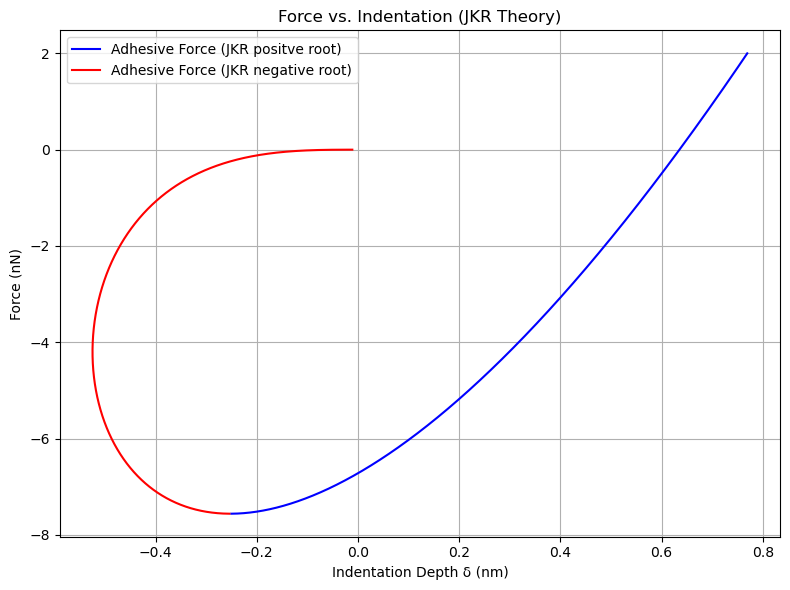

In [498]:
# Plot Force vs Indentation
plt.figure(figsize=(8, 6))
plt.plot(delta_vals_pos * 1e9, f_vals * 1e9, label='Adhesive Force (JKR positve root)', color='blue')
plt.plot(delta_vals_neg * 1e9, f_vals * 1e9, label='Adhesive Force (JKR negative root)', color='red')
plt.xlabel('Indentation Depth δ (nm)')
plt.ylabel('Force (nN)')
plt.title('Force vs. Indentation (JKR Theory)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()